<a href="https://colab.research.google.com/github/Maryam-Skaik/diabetes-prediction-ml-pipeline/blob/main/notebook/Diabetes-Prediction-End-to-End-ML-Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Prediction

## Objective
The goal is to build a classification model that predicts whether a patient has diabetes based on diagnostic medical features.

## Task Type
Binary classification:
- 0 → No diabetes
- 1 → Diabetes

## Imports

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay, recall_score, precision_score, accuracy_score

from sklearn.inspection import permutation_importance

## Custom Functions

In [ ]:
def classification_metrics(y_true, y_pred, label='', output_dict=False, figsize=(8,4), normalize='true', cmap='Blues', colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)

  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)

  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)

  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=None, cmap='gist_gray', colorbar=colorbar, ax = axes[0],);
  axes[0].set_title("Raw Counts")

  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=normalize, cmap=cmap, colorbar=colorbar, ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")

  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()

  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict

In [ ]:
def evaluate_classification(model, X_train, y_train, X_test, y_test, figsize=(6,4), normalize='true', output_dict = False, cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)

  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, output_dict=True, figsize=figsize, colorbar=colorbar, cmap=cmap_train, label='Training Data')
  print()

  # Get predictions for test data
  y_test_pred = model.predict(X_test)

  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, output_dict=True,figsize=figsize, colorbar=colorbar, cmap=cmap_test, label='Test Data' )

  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train, 'test': results_test}
    return results_dict

In [ ]:
def plot_importance(importances, top_n=None, figsize=(8,6)):

    # If DataFrame is passed, convert to Series
    if isinstance(importances, pd.DataFrame):
        importances = importances.set_index("Feature")["Importance"]

    if top_n is None:
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"

    ax = plot_vals.plot(kind='barh', figsize=figsize)
    ax.set(xlabel='Importance', ylabel='Feature Names', title=title)

    return ax

In [ ]:
def plot_coeffs(coeffs, top_n=None, figsize=(4,5), intercept=False):
  if (intercept==False) & ('intercept' in coeffs.index):
    coeffs = coeffs.drop('intercept')

  if top_n==None:
    ## sort all features and set title
    plot_vals = coeffs.sort_values()
    title = "All Coefficients - Ranked by Magnitude"
  else:
    ## rank the coeffs and select the top_n
    coeff_rank = coeffs.abs().rank().sort_values(ascending=False)
    top_n_features = coeff_rank.head(top_n)
    plot_vals = coeffs.loc[top_n_features.index].sort_values()
    ## sort features and keep top_n and set title
    title = f"Top {top_n} Largest Coefficients"

  ## plotting top N importances
  ax = plot_vals.plot(kind='barh', figsize=figsize)
  ax.set(xlabel='Coefficient', ylabel='Feature Names', title=title)
  ax.axvline(0, color='k')

  ## return ax in case want to continue to update/modify figure
  return ax

In [ ]:
def convert_probs_to_preds(probabilities, threshold, pos_class=1):
  predictions = [1 if prob[pos_class] > threshold else 0 for prob in probabilities]
  return predictions

## Load Data

In [ ]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/Belt Exam/Data/Belt2_B_diabetes_v2_final.csv'
df = pd.read_csv(fpath)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,WeightGroup,AgeGroup,Gender,Outcome
0,4,189.0,110.0,31.0,NaN,0_68,overweight,18 - 44,F,0
1,2,157.0,74.0,35.0,440.0,0.134,obese_2,18 - 44,F,0
2,6,98.0,58.0,33.0,190.0,0.43,obese_1,18 - 44,F,0
3,6,111.0,64.0,39.0,NaN,0.26,obese_1,18 - 44,F,0
4,3,106.0,72.0,NaN,NaN,0_207,overweight,18 - 44,F,0


**Dataset Overview**

This dataset contains medical and demographic information used to predict the likelihood of diabetes in patients based on diagnostic measurements and personal attributes

**Features**

- `Pregnancies` indicates number of times pregnant for a patient.

- `Glucose` represents plasma glucose concentration.

- `BloodPressure` represents diastolic blood pressure.

- `SkinThickness` measures triceps skin fold thickness.

- `Insulin` represents serum insulin levels and contains missing values.

- `DiabetesPedigreeFunction` indicates genetic risk score for diabetes.

- `WeightGroup` represents categorized body weight status such as overweight or obese.

- `AgeGroup` represents grouped age ranges of patients
Gender indicates patient gender


**Feature Types**

- Numerical features:  include (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, DiabetesPedigreeFunction).

- Categorical features: include (Gender).

- Ordinal features: include (WeightGroup and AgeGroup) since both follow a meaningful ordered structure

**Target Variable**

- `Outcome` is the target feature where 0 indicates no diabetes and 1 indicates presence of diabetes

Notes:

- Insulin and SkinThickness columns contain missing values that may require handling during preprocessing.
- Some features may require encoding depending on model requirements.
- DiabetesPedigreeFunction columns contains some numbers with _ instead of ., so need to handle and fix.

## Data Understanding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 642 entries, 0 to 641
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               642 non-null    int64  
 1   Glucose                   638 non-null    float64
 2   BloodPressure             616 non-null    float64
 3   SkinThickness             455 non-null    float64
 4   Insulin                   331 non-null    float64
 5   DiabetesPedigreeFunction  642 non-null    object 
 6   WeightGroup               642 non-null    object 
 7   AgeGroup                  642 non-null    object 
 8   Gender                    642 non-null    object 
 9   Outcome                   642 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 50.3+ KB


- Dataset contains 642 rows and 10 columns  
- Data types are generally consistent with feature meanings, except DiabetesPedigreeFunction exist as object while it must be float.
- Some features contain missing values, specifically `Glucose`, `BloodPressure`, `SkinThickness`, and `Insulin`  
- Missing values exist only in numerical columns and will require imputation during preprocessing before model training

In [ ]:
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,Outcome
count,642.00,638.00,616.00,455.00,331.00,642.00
mean,5.45,124.04,72.40,29.48,159.00,0.42
std,39.46,30.76,12.31,10.53,117.26,0.49
min,0.00,56.00,24.00,7.00,14.00,0.00
25%,1.00,100.00,64.00,22.00,82.50,0.00
50%,3.00,121.00,72.00,30.00,130.00,0.00
75%,6.00,144.00,80.00,36.50,192.50,1.00
max,1000.00,199.00,114.00,99.00,846.00,1.00


- `Pregnancies` has a max of 1000, which is biologically impossible.
  Confirmed as a data entry error — the 75th percentile is just 6, with std of 39.46

- `Glucose` ranges from 56–199 mg/dL.

- `BloodPressure` ranges from 24–114 mmHg (diastolic).

- `Insulin` ranges from 14–846 µU/mL.

- `SkinThickness` ranges from 7–99 mm.

- **Summary:** Only `Pregnancies` contained a genuinely impossible value and must correcte.

In [ ]:
df[df['Pregnancies'] >= 20]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,WeightGroup,AgeGroup,Gender,Outcome
371,1000,163.0,72.0,41.0,114.0,0.8170000000000001,obsese_3,45 - 64,F,1


In [ ]:
df['Pregnancies'] = df['Pregnancies'].clip(upper=20)

In [ ]:
df[df['Insulin'] > 200]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,WeightGroup,AgeGroup,Gender,Outcome
1,2,157.0,74.0,35.0,440.0,0.134,obese_2,18 - 44,F,0
20,3,123.0,100.0,35.0,240.0,0.88,obsese_3,18 - 44,F,0
23,4,129.0,60.0,12.0,231.0,0.527,overweight,18 - 44,F,0
38,0,91.0,68.0,32.0,210.0,0.381,obese_2,18 - 44,M,0
41,7,124.0,70.0,33.0,215.0,0.161,overweight,18 - 44,F,0
...,...,...,...,...,...,...,...,...,...,...
628,3,170.0,64.0,37.0,225.0,0.35600000000000004,obese_1,18 - 44,F,1
631,3,158.0,70.0,30.0,328.0,0.344,obese_2,18 - 44,F,1
635,8,196.0,76.0,29.0,280.0,0.605,obese_2,45 - 64,F,1
637,5,144.0,82.0,26.0,285.0,0.452,obese_1,45 - 64,F,1


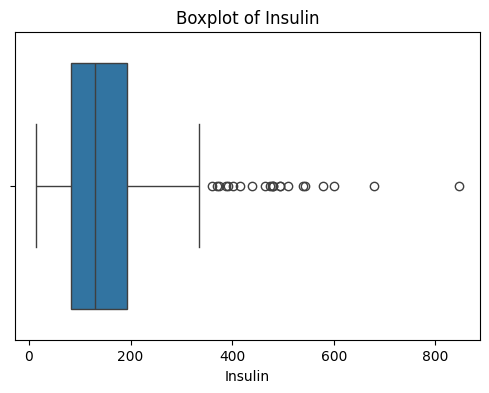

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Insulin"])
plt.title("Boxplot of Insulin")
plt.show()

- The boxplot of Insulin shows a strong right skew with many high-value outliers above the upper whisker (~320 µU/mL)

- Most observed values are concentrated in a relatively low range (around 50–200), with a median close to ~100–130

- Several extreme values extend up to ~800+.

- A large portion of Insulin values in the dataset are missing, so this distribution represents only the recorded subset of patients

- Since more than half of the target class is non-diabetic (class 0), the low Insulin values are also partially expected in the dataset distribution

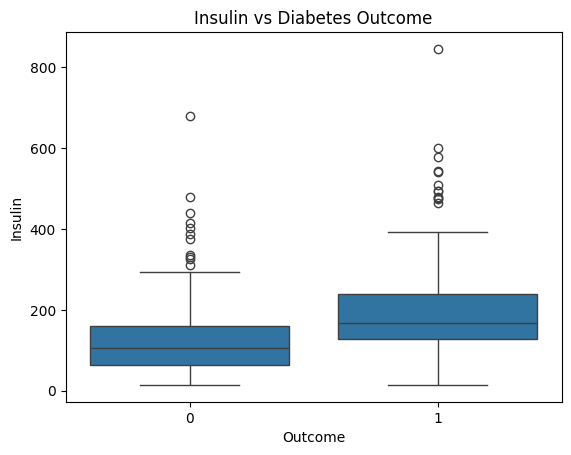

In [ ]:
sns.boxplot(x="Outcome", y="Insulin", data=df)
plt.title("Insulin vs Diabetes Outcome")
plt.show()

- Insulin levels are clearly higher in diabetic patients (Outcome = 1), with a higher median (~160) compared to non-diabetics (100 µU/mL)

- The spread of values is also larger for diabetic patients compared to non-diabetics, indicating higher variability in this group

- The upper range is more extended in the diabetic class, with higher extreme values reaching above 400, while non-diabetics are generally lower

- Both classes contain extreme outliers, including very high insulin values (e.g., ~680 in class 0 and ~846 in class 1), which may reflect rare or noisy medical measurements

- The presence of a high outlier in the non-diabetic group is clinically unusual and may indicate data noise or exceptional cases

- Despite class imbalance favoring non-diabetics, the separation in insulin distribution is clear and suggests a real relationship between insulin levels and diabetes outcome

## Duplicates

In [ ]:
df.duplicated().sum()

np.int64(3)

In [ ]:
df[df.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,WeightGroup,AgeGroup,Gender,Outcome
463,1,126.0,60.0,NaN,NaN,0.349,obese_1,45 - 64,F,1
601,8,183.0,64.0,NaN,NaN,0.672,healthy weight,18 - 44,F,1
618,0,137.0,40.0,35.0,168.0,2.2880000000000003,obsese_3,18 - 44,M,1


In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

- Dataset contains 3 duplicate records, we handle them by drop duplicated ones, which must handle before modeling and before split data, to avoid data leakage

## Missing Values Check

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,4
BloodPressure,26
SkinThickness,185
Insulin,309
DiabetesPedigreeFunction,0
WeightGroup,0
AgeGroup,0
Gender,0
Outcome,0


In [ ]:
(df.isnull().sum() / len(df) * 100).round(2)

,0
Pregnancies,0.00
Glucose,0.63
BloodPressure,4.07
SkinThickness,28.95
Insulin,48.36
DiabetesPedigreeFunction,0.00
WeightGroup,0.00
AgeGroup,0.00
Gender,0.00
Outcome,0.00


- As observed from the data inspection(`df.info()`), missing values exist in `Glucose`, `BloodPressure`, `SkinThickness`, and `Insulin`.

- The amount of missing data varies significantly, with Insulin and SkinThickness having the highest proportions.

- Missing values will be handled during preprocessing using median imputation for numerical features.

- Median is preferred as it is more robust to outliers, which are common in medical datasets.

## Inconsistencies

In [ ]:
df['DiabetesPedigreeFunction'].value_counts()

,count
DiabetesPedigreeFunction,
0.254,5
0.23800000000000002,4
0.258,4
0.27,4
0.259,4
...,...
0.5870000000000001,1
0.732,1
0.63,1


In [ ]:
df['DiabetesPedigreeFunction'] = df['DiabetesPedigreeFunction'].str.replace('_', '.')
df['DiabetesPedigreeFunction'] = df['DiabetesPedigreeFunction'].astype(float)
df['DiabetesPedigreeFunction'] = df['DiabetesPedigreeFunction'].round(2)
df['DiabetesPedigreeFunction'].value_counts()

,count
DiabetesPedigreeFunction,
0.26,30
0.24,22
0.14,17
0.34,17
0.20,16
...,...
1.13,1
1.29,1
1.89,1


- Diabetes Pedigree Function was handled by replace _ with ., and then safely convert it's type from object to float, finally we round it's values so become more readable

In [ ]:
for col in df.select_dtypes("object").columns:
    print(col, df[col].value_counts())

WeightGroup WeightGroup
obese_1           195
overweight        146
obese_2           126
obsese_3           86
healthy weight     74
MISSING             8
underweight         4
Name: count, dtype: int64
AgeGroup AgeGroup
18 - 44    526
45 - 64    102
>65          8
<65          3
Name: count, dtype: int64
Gender Gender
F    563
M     59
m     17
Name: count, dtype: int64


- We noted that Weight group have a placeholder 'MISSING', so we will handle it by replace placeholder with np.nan

- Then we will impute missing values with most frequent value (mode) before modeling.

- Also Gender have m and M, so will replace m with M.

- Age Group have 3 values as <65, where this value isn't exist in dictionary, so we will replace it with >65

- Weight group contains obsese_3 instead of obese_3, need handle by correct it.

In [ ]:
df['WeightGroup'].isna().sum()

np.int64(0)

In [ ]:
df['WeightGroup'] = df['WeightGroup'].replace('MISSING', np.nan)

In [ ]:
df['WeightGroup'].isna().sum()

np.int64(8)

In [ ]:
df['WeightGroup'] = df['WeightGroup'].replace('obsese_3', 'obese_3')

In [ ]:
df['Gender'] = df['Gender'].replace('m', 'M')
df['Gender'].value_counts()

,count
Gender,
F,563
M,76


In [ ]:
df['AgeGroup'] = df['AgeGroup'].replace('<65', '>65')
df['AgeGroup'].value_counts()

,count
AgeGroup,
18 - 44,526
45 - 64,102
>65,11


In [ ]:
for col in df.select_dtypes("object").columns:
    print(col, df[col].value_counts())

WeightGroup WeightGroup
obese_1           195
overweight        146
obese_2           126
obese_3            86
healthy weight     74
underweight         4
Name: count, dtype: int64
AgeGroup AgeGroup
18 - 44    526
45 - 64    102
>65         11
Name: count, dtype: int64
Gender Gender
F    563
M     76
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

### Target Distribution

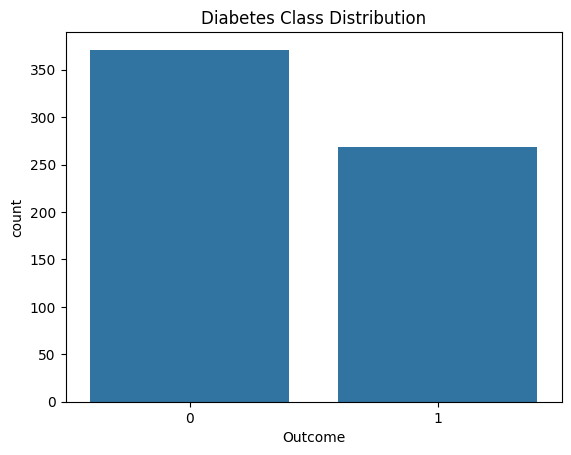

In [ ]:
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Class Distribution")
plt.show()

In [ ]:
df['Outcome'].value_counts(normalize=True)

,proportion
Outcome,
0,0.580595
1,0.419405


- We observe from the distribution that the target feature is relatively balanced, with a slight majority of class 0

- This supports using accuracy as a reliable evaluation metric, as results are less likely to be misleading due to class imbalance

### Feature Correlation

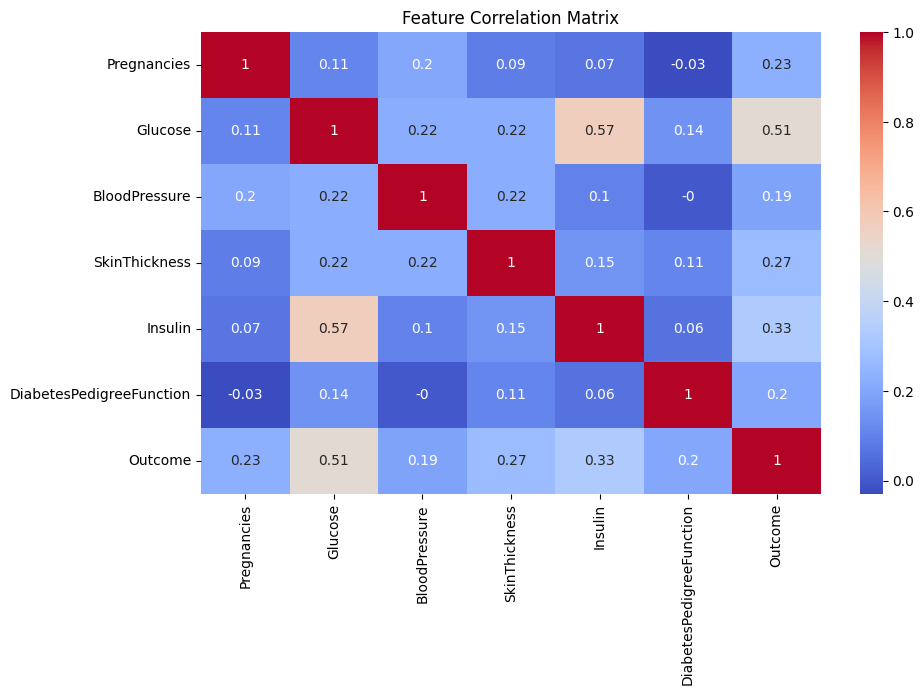

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True).round(2), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

- Glucose shows the strongest correlation with Outcome, making it the most important predictor.
- Insulin and SkinThickness have moderate correlation with Outcome, contributing useful signals  
- Pregnancies and DiabetesPedigreeFunction show weaker but noticeable relationships  
- BloodPressure has the weakest correlation with Outcome and may have limited impact  

- Glucose and Insulin are moderately correlated with each other.
- Other feature correlations are low.

- Some features show near-zero correlation, indicating independence and no direct relationship

### Distribution

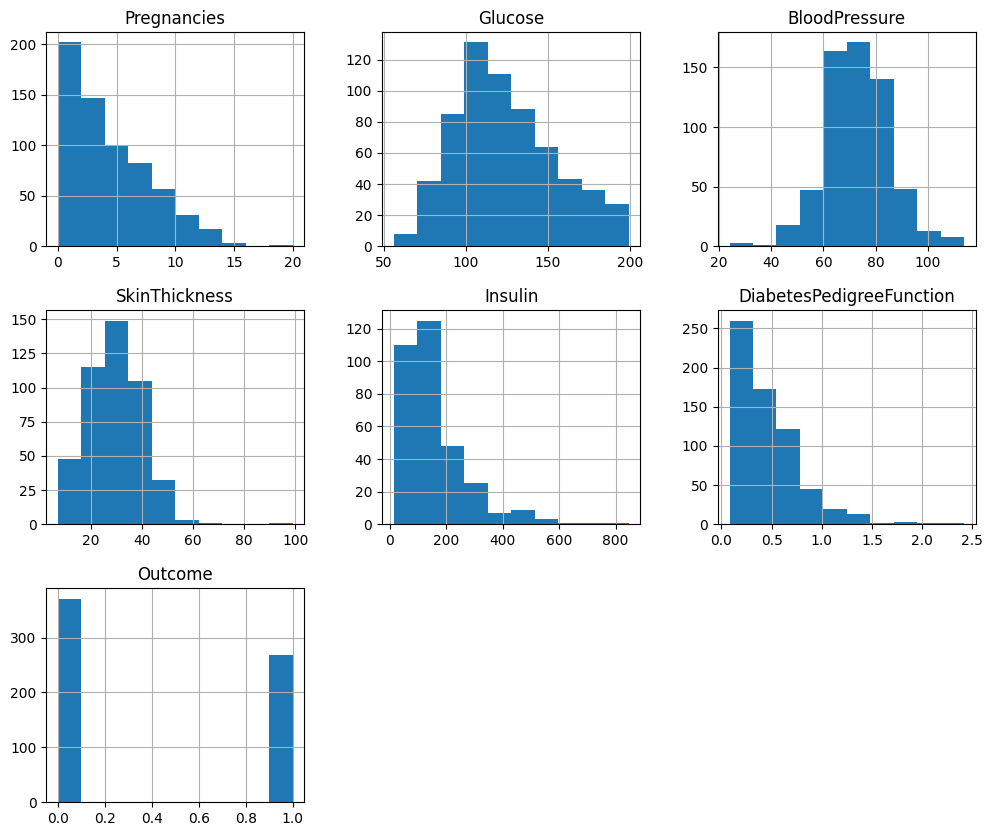

In [ ]:
df.hist(figsize=(12,10))
plt.show()

- Pregnancies is right-skewed, with most values in lower range and a long tail.  
- Glucose is approximately normally distributed with slight right skew  
- BloodPressure is close to normal and centered around typical values  
- SkinThickness shows slight right skew but remains within a reasonable range  
- Insulin is heavily right-skewed with a long tail, which may require transformation for some models  
- DiabetesPedigreeFunction is also right-skewed with most values concentrated at lower range  

- Most features are reasonably distributed, but Insulin and DiabetesPedigreeFunction may benefit from transformation if using linear models  

## Feature Setup

In [ ]:
y = df['Outcome']
X = df.drop(columns='Outcome')

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## Preprocessing

In [ ]:
num_cols = X_train.select_dtypes('number').columns

impute_num = SimpleImputer(strategy='median')
scaler = StandardScaler()

num_pipe = make_pipeline(impute_num, scaler)

num_tuple = ('num', num_pipe, num_cols)
num_tuple

('num',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                 ('standardscaler', StandardScaler())]),
 Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
        'DiabetesPedigreeFunction'],
       dtype='object'))

In [ ]:
ord_cols = ['AgeGroup', 'WeightGroup']

age_order = ['18 - 44', '45 - 64', '>65']
weight_order = ['underweight', 'healthy weight', 'overweight', 'obese_1', 'obese_2', 'obese_3']

ordinal_category_orders = [age_order, weight_order]

impute_ord = SimpleImputer(strategy='most_frequent')
ord_encoder = OrdinalEncoder(categories=ordinal_category_orders)
scaler = StandardScaler()

ord_pipe = make_pipeline(impute_ord, ord_encoder, scaler)

ord_tuple = ('ord', ord_pipe, ord_cols)
ord_tuple

('ord',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                 ('ordinalencoder',
                  OrdinalEncoder(categories=[['18 - 44', '45 - 64', '>65'],
                                             ['underweight', 'healthy weight',
                                              'overweight', 'obese_1', 'obese_2',
                                              'obese_3']])),
                 ('standardscaler', StandardScaler())]),
 ['AgeGroup', 'WeightGroup'])

- Selected ordinal features: AgeGroup and WeightGroup  
- Defined a meaningful order for each feature to preserve their natural ranking  
- Applied most frequent imputation to handle any potential missing values  
- Encoded ordinal features using OrdinalEncoder with predefined category order  
- Applied scaling after encoding to normalize values for models sensitive to feature magnitude  

* Median imputation was used for numeric features because these variables contain outliers and skewed distributions

* The median is more robust than the mean in such cases, as it is not affected by extreme values and better represents the central tendency of the data

* Most frequent (mode) imputation was used for categorical features because it preserves the most common category and does not introduce unrealistic values

* This approach maintains the original distribution of categories as much as possible

* Imputation was applied within the preprocessing pipeline after splitting the data, ensuring that statistics are learned only from the training set

* This prevents data leakage and ensures that the model does not gain information from the test set during training

* Overall, the imputation strategy was chosen based on the nature of each feature type, balancing robustness, simplicity, and prevention of data leakage

In [ ]:
cat_cols = ['Gender']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

cat_tuple = ('cat', ohe, cat_cols)
cat_tuple

('cat',
 OneHotEncoder(handle_unknown='ignore', sparse_output=False),
 ['Gender'])

- Ordinal encoding was used for AgeGroup and WeightGroup because both features have a clear and meaningful order  
- AgeGroup follows a natural progression from younger to older age ranges, making ordinal representation appropriate  
- WeightGroup represents increasing levels of body weight severity, which also has an inherent ranking from underweight to obese categories  

- Preserving this order is important because it allows the model to learn monotonic relationships between these categories and the target variable  
- Using one-hot encoding for these features would remove the ordering information and increase dimensionality unnecessarily  

- One-hot encoding was used for Gender because it is a nominal feature with no inherent order between categories  
- Encoding Gender as separate binary columns prevents the model from incorrectly assuming any ordinal relationship  

- Overall, the encoding strategy is chosen based on whether the feature has a meaningful order or not, ensuring both interpretability and correct representation of categorical information  

In [ ]:
preprocessor = ColumnTransformer([num_tuple, ord_tuple, cat_tuple], verbose_feature_names_out=False)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction'],
      dtype='object')),
                                ('ord',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(categories=[['18 '
                                                                              '- '
                                                                              '44',
                                                                              '45 '
                                                                              '- '
                                                                              '64',
                                                                              '>65'],
                                                                             ['underweight',
                                                                              'healthy '
                                                                              'weight',
                                                                              'overweight',
                                                                              'obese_1',
                                                                              'obese_2',
                                                                              'obese_3']])),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['AgeGroup', 'WeightGroup']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Gender'])],
                  verbose_feature_names_out=False)

## Model Pipeline

### Model 1: Logistic Regression

In [ ]:
lr = LogisticRegression()
lr_pipe = make_pipeline(preprocessor, lr)
lr_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction'],
      dtype='object')),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImput...
                                                                   OrdinalEncoder(categories=[['18 '
                                                                                               '- '
                                                                                               '44',
                                                                                               '45 '
                                                                                               '- '
                                                                                               '64',
                                                                                               '>65'],
                                                                                              ['underweight',
                                                                                               'healthy '
                                                                                               'weight',
                                                                                               'overweight',
                                                                                               'obese_1',
                                                                                               'obese_2',
                                                                                               'obese_3']])),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['AgeGroup', 'WeightGroup']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender'])],
                                   verbose_feature_names_out=False)),
                ('logisticregression', LogisticRegression())])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.76      0.80      0.78       260
           1       0.75      0.70      0.72       219

    accuracy                           0.76       479
   macro avg       0.75      0.75      0.75       479
weighted avg       0.76      0.76      0.75       479



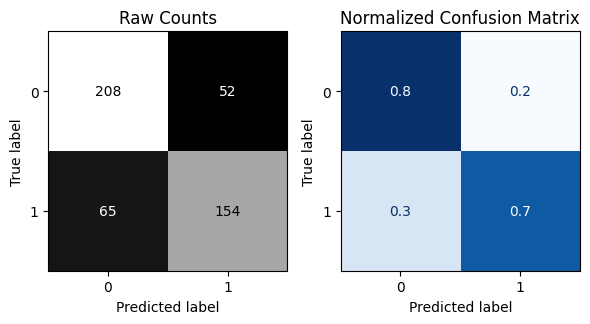


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       111
           1       0.57      0.65      0.61        49

    accuracy                           0.74       160
   macro avg       0.70      0.72      0.71       160
weighted avg       0.76      0.74      0.75       160



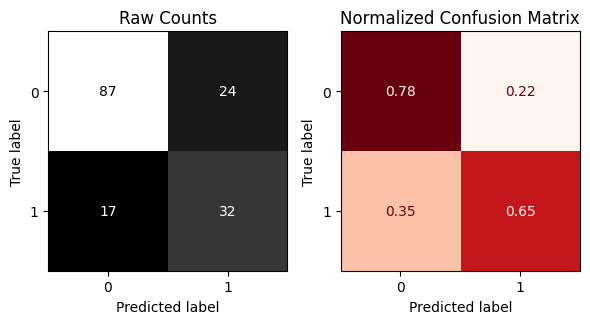

In [ ]:
evaluate_classification(lr_pipe, X_train, y_train, X_test, y_test)

- The default Logistic Regression model shows stable training performance with reasonable generalization to the test set  

- Training accuracy is 0.76, while test accuracy is slightly lower at 0.74, indicating a small generalization gap  

- Class 0 (non-diabetic) is predicted significantly better than Class 1 (diabetic), especially on the test set  

- Recall for Class 1 is 0.70 in training and drops to 0.65 in testing, showing that a noticeable number of diabetic cases are still missed  

- On the test set, Class 1 performance is weaker overall (precision 0.57, recall 0.65), indicating difficulty in detecting positive cases  

- Class 0 maintains stronger performance with higher recall and precision, which biases the model toward the majority class  

- Macro averages are lower than weighted averages, confirming that class imbalance has a noticeable effect on performance  

- Overall, the model is balanced in training but struggles more with the minority class in unseen data, highlighting the need for tuning.

#### Hyperparameter Tuning

In [ ]:
lr_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('num',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
          'DiabetesPedigreeFunction'],
         dtype='object')),
                                   ('ord',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('ordinalencoder',
                                                     OrdinalEncoder(categories=[['18 '
                                                          

In [ ]:
grid_params_lr = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l2'],
    'logisticregression__solver': ['lbfgs', 'liblinear'],
    'logisticregression__class_weight': [None, 'balanced'],
    'logisticregression__max_iter': [100, 200, 500]
}

- C is included because it controls regularization strength, which directly affects overfitting and underfitting  
- Penalty is included to define the type of regularization applied, which influences how the model handles feature weights  
- Solver is included because different solvers support different penalties and can affect performance  
- class_weight is included to handle potential class imbalance and improve sensitivity toward minority class predictions  
- max_iter is included to ensure the model converges properly, especially when regularization or solver settings make optimization harder  

- l1_ratio is excluded because it only applies to elasticnet penalty, which is not used in this configuration

In [ ]:
lr_gs = GridSearchCV(lr_pipe, grid_params_lr, cv=3, n_jobs=-1, verbose=1, scoring='recall_macro')
lr_gs.fit(X_train, y_train)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction'],
      dtype='object')),
                                                                        ('ord',
                                                                         Pipeline(steps=[...
                                                          verbose_feature_names_out=False)),
                                       ('logisticregression',
                                        LogisticRegression())]),
             n_jobs=-1,
             param_grid={'logisticregression__C': [0.01, 0.1, 1, 10, 100],
                         'logisticregression__class_weight': [None, 'balanced'],
                         'logisticregression__max_iter': [100, 200, 500],
                         'logisticregression__penalty': ['l2'],
                         'logisticregression__solver': ['lbfgs', 'liblinear']},
             scoring='recall_macro', verbose=1)

In [ ]:
lr_gs.best_params_

{'logisticregression__C': 0.1,
 'logisticregression__class_weight': 'balanced',
 'logisticregression__max_iter': 100,
 'logisticregression__penalty': 'l2',
 'logisticregression__solver': 'lbfgs'}

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.78      0.78      0.78       260
           1       0.74      0.74      0.74       219

    accuracy                           0.76       479
   macro avg       0.76      0.76      0.76       479
weighted avg       0.76      0.76      0.76       479



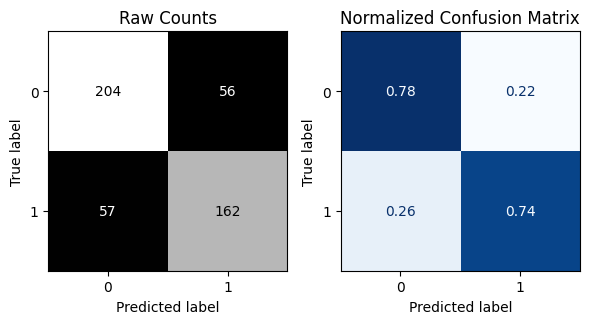


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.74      0.79       111
           1       0.54      0.69      0.61        49

    accuracy                           0.72       160
   macro avg       0.69      0.72      0.70       160
weighted avg       0.75      0.72      0.73       160



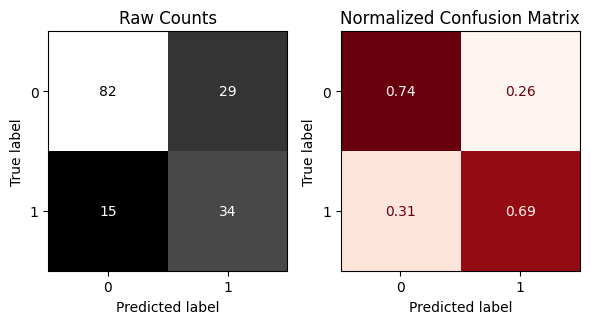

In [ ]:
evaluate_classification(lr_gs.best_estimator_, X_train, y_train, X_test, y_test)

- After hyperparameter tuning using cross-validation, the best configuration was selected with C = 0.1 and class_weight = balanced  
- The smaller C value increased regularization strength, helping reduce overfitting and improving generalization  
- Using class_weight = balanced improved the model’s ability to handle class imbalance and better learn the minority class  

- Overall accuracy on the test set is 0.72, which is lower than the default model after tuning  

- Macro and weighted averages show a slight decrease, indicating less balanced performance across classes  

- For the positive class (diabetes cases), recall improved from 0.65 (default model) to 0.69, showing better sensitivity and fewer missed diabetic cases  

- This improvement in recall comes with a trade-off, as precision for the positive class decreased, meaning more false positives are introduced  

- F1-score for the positive class remains stable, indicating a trade-off between precision and recall rather than a clear improvement  

- Training and test performance remain relatively close, suggesting the model is still generalizing without strong overfitting  

- Overall, the model shifts toward better detection of diabetic cases at the cost of reduced overall accuracy and precision balance  

#### Coefficients

In [ ]:
best_model = lr_gs.best_estimator_

In [ ]:
feature_names = best_model.named_steps["columntransformer"].get_feature_names_out()
coefficients = best_model.named_steps["logisticregression"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
1,Glucose,0.987660
7,WeightGroup,0.551945
0,Pregnancies,0.448000
5,DiabetesPedigreeFunction,0.343102
4,Insulin,0.153877
2,BloodPressure,0.105197
3,SkinThickness,0.016554
8,Gender_F,0.010797
6,AgeGroup,0.003814
9,Gender_M,-0.012238


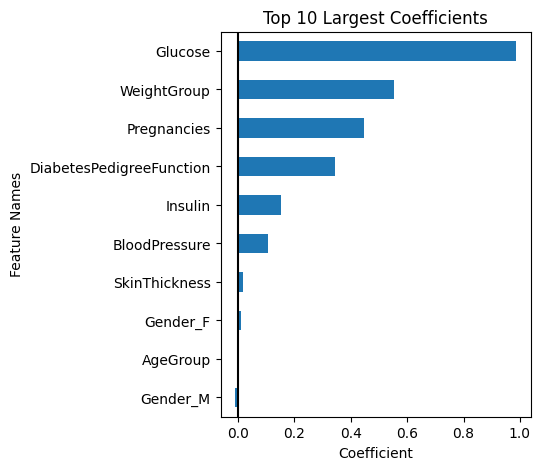

In [ ]:
plot_coeffs(coef_df.set_index("Feature")["Coefficient"], top_n=10);

- Logistic Regression coefficients were extracted to interpret how each feature contributes to the prediction of diabetes  
- Positive coefficients indicate features that increase the likelihood of predicting diabetes, while negative coefficients indicate a slight decrease in risk  

- Glucose is the most influential feature with the highest positive coefficient, confirming it as the strongest predictor

- Pregnancies and WeightGroup also show strong positive contributions, indicating a meaningful relationship with diabetes risk

- DiabetesPedigreeFunction has a moderate positive effect, reflecting genetic influence on the outcome

- SkinThickness and BloodPressure have weaker but still positive contributions to the prediction  

- AgeGroup and Gender have very small coefficients, indicating limited impact on model decisions

- Insulin has nearly zero effect in this model, suggesting it is not strongly used by Logistic Regression after preprocessing  

- Gender features show minimal influence, with slight positive and negative effects that are not significant  

- Overall, the model is mainly driven by Glucose, followed by lifestyle and demographic factors, while some clinical features contribute less after regularization  

### Model 2: KNN

In [ ]:
knn = KNeighborsClassifier()
knn_pipe = make_pipeline(preprocessor, knn)
knn_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction'],
      dtype='object')),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImput...
                                                                   OrdinalEncoder(categories=[['18 '
                                                                                               '- '
                                                                                               '44',
                                                                                               '45 '
                                                                                               '- '
                                                                                               '64',
                                                                                               '>65'],
                                                                                              ['underweight',
                                                                                               'healthy '
                                                                                               'weight',
                                                                                               'overweight',
                                                                                               'obese_1',
                                                                                               'obese_2',
                                                                                               'obese_3']])),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['AgeGroup', 'WeightGroup']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender'])],
                                   verbose_feature_names_out=False)),
                ('kneighborsclassifier', KNeighborsClassifier())])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.79      0.80       260
           1       0.76      0.79      0.78       219

    accuracy                           0.79       479
   macro avg       0.79      0.79      0.79       479
weighted avg       0.79      0.79      0.79       479



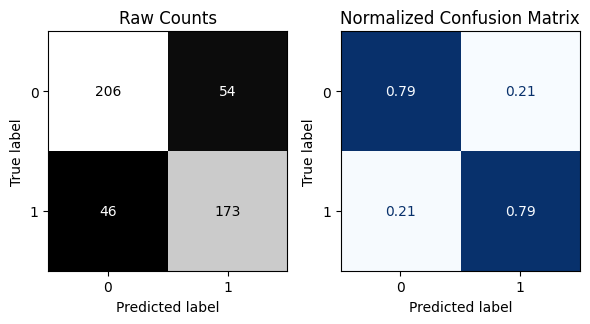


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.71      0.77       111
           1       0.51      0.67      0.58        49

    accuracy                           0.70       160
   macro avg       0.67      0.69      0.67       160
weighted avg       0.73      0.70      0.71       160



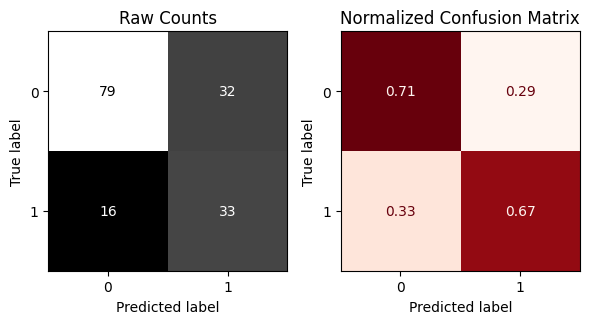

In [ ]:
evaluate_classification(knn_pipe, X_train, y_train, X_test, y_test)

- KNN model shows strong performance on training data with 0.79 accuracy, indicating good fit to the training patterns  

- Training performance is slightly higher than Logistic Regression, but still remains balanced without extreme overfitting  

- On test data, performance drops to 0.70 accuracy, showing weaker generalization compared to Logistic Regression  

- Recall for the positive class (diabetic cases) is 0.67 in KNN, which is lower than the tuned Logistic Regression model  

- This indicates that KNN misses more diabetic cases, leading to higher false negatives in comparison  

- Class 0 (non-diabetic) is predicted better than class 1, showing a bias toward the majority class  

- Logistic Regression still provides better recall for the target class and more stable test performance overall  

- Overall, KNN is less suitable for this problem due to weaker generalization and lower sensitivity to diabetic cases  

#### Hyperparameter Tuning

In [ ]:
knn_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('num',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
          'DiabetesPedigreeFunction'],
         dtype='object')),
                                   ('ord',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('ordinalencoder',
                                                     OrdinalEncoder(categories=[['18 '
                                                          

In [ ]:
grid_params_knn = {
    'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'kneighborsclassifier__weights': ['uniform', 'distance'],
    'kneighborsclassifier__p': [1, 2],
    'kneighborsclassifier__algorithm': ['auto', 'ball_tree', 'kd_tree']
}

- n_neighbors is included because it controls the number of samples used to decide the class, which strongly impacts bias and variance trade-off  
- weights is included because it determines whether all neighbors contribute equally or closer neighbors have more influence, which is important in medical data  
- p is included because it defines the distance metric (Manhattan or Euclidean), which can significantly change neighborhood structure and model behavior  
- algorithm is included mainly for computational efficiency and can slightly affect performance depending on data size and structure

In [ ]:
knn_gs = GridSearchCV(knn_pipe, grid_params_knn, n_jobs=-1, verbose=1, cv=3, scoring='recall_macro')
knn_gs.fit(X_train, y_train)

Fitting 3 folds for each of 84 candidates, totalling 252 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction'],
      dtype='object')),
                                                                        ('ord',
                                                                         Pipeline(steps=[...
                                                                         ['Gender'])],
                                                          verbose_feature_names_out=False)),
                                       ('kneighborsclassifier',
                                        KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'kneighborsclassifier__algorithm': ['auto',
                                                             'ball_tree',
                                                             'kd_tree'],
                         'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11,
                                                               15, 21],
                         'kneighborsclassifier__p': [1, 2],
                         'kneighborsclassifier__weights': ['uniform',
                                                           'distance']},
             scoring='recall_macro', verbose=1)

In [ ]:
knn_gs.best_params_

{'kneighborsclassifier__algorithm': 'auto',
 'kneighborsclassifier__n_neighbors': 21,
 'kneighborsclassifier__p': 2,
 'kneighborsclassifier__weights': 'distance'}

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       260
           1       1.00      1.00      1.00       219

    accuracy                           1.00       479
   macro avg       1.00      1.00      1.00       479
weighted avg       1.00      1.00      1.00       479



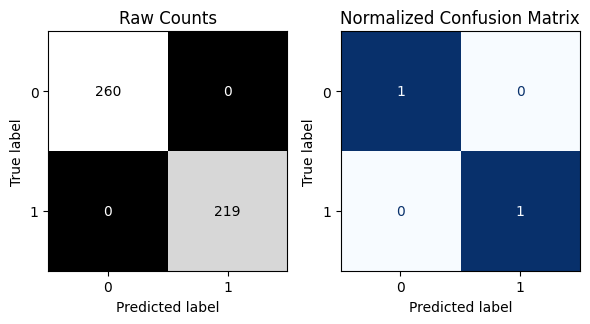


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.70      0.77       111
           1       0.51      0.71      0.60        49

    accuracy                           0.71       160
   macro avg       0.68      0.71      0.68       160
weighted avg       0.75      0.71      0.72       160



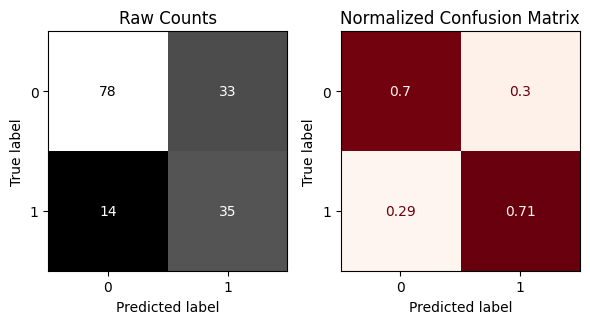

In [ ]:
evaluate_classification(knn_gs.best_estimator_, X_train, y_train, X_test, y_test)

- After hyperparameter tuning, the best KNN configuration used 21 neighbors with Euclidean distance (p=2) and distance-based weighting  
- Using a higher number of neighbors (21) with distance weighting improved model smoothness and reduced sensitivity to noise  

- Training performance reached 1.00 accuracy, indicating the model fits the training data extremely well, likely due to KNN memorization behavior  
- On test data, accuracy is 0.71, showing a clear drop from training performance and indicating reduced generalization  

- Recall for the positive class (diabetes cases) improved to 0.71, showing better detection of diabetic patients compared to previous KNN versions  
- However, precision for class 1 decreased, meaning more false positives are introduced as a trade-off  

- Class 0 performance is stronger in precision than recall, showing a bias toward correct negative predictions but weaker detection of positives  

- Compared to Logistic Regression, KNN now achieves similar recall for the positive class but remains less stable overall due to overfitting behavior in training  

- Overall, tuning improved KNN’s sensitivity to diabetic cases, but Logistic Regression still provides more balanced and reliable generalization  

#### Permutation Importance

In [ ]:
perm_knn = permutation_importance(knn_gs.best_estimator_, X_test, y_test, n_repeats=10, random_state=42)

knn_perm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_knn.importances_mean
}).sort_values(by="Importance", ascending=False)

knn_perm_importance

,Feature,Importance
1,Glucose,0.121250
5,DiabetesPedigreeFunction,0.014375
4,Insulin,0.011250
6,WeightGroup,0.010000
0,Pregnancies,0.009375
8,Gender,0.003750
3,SkinThickness,0.002500
7,AgeGroup,-0.003125
2,BloodPressure,-0.008125


- Permutation importance was used to measure the impact of each feature on model performance by observing the change in accuracy when each feature is randomly shuffled  
- This approach reflects how much the model truly depends on each feature for making correct predictions  

- Glucose is the most important feature by a large margin, confirming it as the strongest predictor of diabetes in the model  
- DiabetesPedigreeFunction shows a small but noticeable contribution, indicating some influence on prediction behavior  
- Insulin has very low importance, suggesting limited impact in this model despite its clinical relevance  
- WeightGroup and Pregnancies contribute weakly but still provide some signal to the model  

- SkinThickness and Gender have minimal importance, showing almost no effect on predictions  
- AgeGroup and BloodPressure show negative importance values, indicating that shuffling these features does not harm and may slightly improve performance, meaning they are not useful in this model configuration  

- Overall, the model is dominated by Glucose, while most other features provide weak or negligible contribution to prediction performance  

### Model 3: Random Forest

In [ ]:
rf = RandomForestClassifier()
rf_pipe = make_pipeline(preprocessor, rf)
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction'],
      dtype='object')),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImput...
                                                                   OrdinalEncoder(categories=[['18 '
                                                                                               '- '
                                                                                               '44',
                                                                                               '45 '
                                                                                               '- '
                                                                                               '64',
                                                                                               '>65'],
                                                                                              ['underweight',
                                                                                               'healthy '
                                                                                               'weight',
                                                                                               'overweight',
                                                                                               'obese_1',
                                                                                               'obese_2',
                                                                                               'obese_3']])),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['AgeGroup', 'WeightGroup']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender'])],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier', RandomForestClassifier())])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       260
           1       1.00      1.00      1.00       219

    accuracy                           1.00       479
   macro avg       1.00      1.00      1.00       479
weighted avg       1.00      1.00      1.00       479



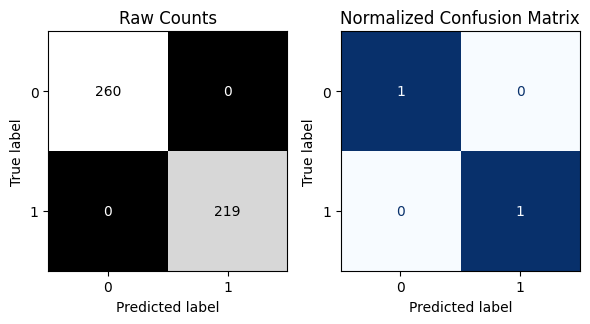


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.71      0.77       111
           1       0.52      0.69      0.59        49

    accuracy                           0.71       160
   macro avg       0.68      0.70      0.68       160
weighted avg       0.74      0.71      0.72       160



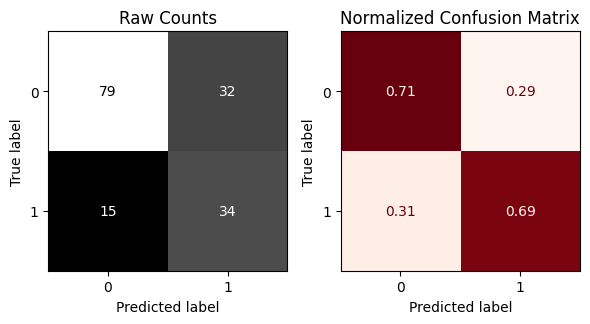

In [ ]:
evaluate_classification(rf_pipe, X_train, y_train, X_test, y_test)

- The default Random Forest model shows clear overfitting, achieving perfect performance on the training data  
- Training accuracy is 1.00 across all metrics, indicating that the model has fully memorized the training set  

- On the test set, performance drops to 0.71 accuracy, showing a significant generalization gap  
- The large difference between training and test performance confirms that the model is not generalizing well  

- For the positive class (diabetes cases), recall is 0.69, which is slightly lower than KNN and Logistic Regression models  
- Precision for the positive class is also low, indicating a relatively high number of false positives  

- Despite perfect training performance, the model does not outperform simpler models on unseen data  
- Overall, the default Random Forest is overfitting heavily and does not provide reliable generalization in its current form  

- This highlights the need for hyperparameter tuning, such as limiting tree depth and adjusting sample constraints, to improve generalization performance  

In [ ]:
rf_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('num',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
          'DiabetesPedigreeFunction'],
         dtype='object')),
                                   ('ord',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('ordinalencoder',
                                                     OrdinalEncoder(categories=[['18 '
                                                          

In [ ]:
grid_params_rf = {
    'randomforestclassifier__n_estimators': [100, 200, 300],
    'randomforestclassifier__max_depth': [None, 5, 10, 20],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4],
    'randomforestclassifier__max_features': ['sqrt', 'log2'],
    'randomforestclassifier__bootstrap': [True, False],
    'randomforestclassifier__class_weight': [None, 'balanced']
}

- Hyperparameter tuning focuses on controlling model complexity and reducing overfitting, which is clearly observed in the default Random Forest results  

- n_estimators is included because increasing the number of trees improves stability and reduces variance  
- max_depth is included to control how deep trees can grow, which directly impacts overfitting  
- min_samples_split is included to prevent trees from creating very small splits that overfit training data  
- min_samples_leaf is included to ensure leaves contain enough samples for more generalized decisions  
- max_features is included to control feature randomness and reduce correlation between trees  
- bootstrap is included because it affects how each tree is trained and can improve generalization  
- class_weight is included to handle class imbalance and improve minority class detection  

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_random = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=grid_params_rf,
    n_iter=80,                        # number of random combinations to try
    cv=3,
    scoring='recall_macro',
    n_jobs=-1,
    verbose=2,
)

rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 80 candidates, totalling 240 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('standardscaler',
                                                                                                StandardScaler())]),
                                                                               Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction'],
      dtype='object')),
                                                                              ('ord',
                                                                               Pipeline(s...
                                        'randomforestclassifier__class_weight': [None,
                                                                                 'balanced'],
                                        'randomforestclassifier__max_depth': [None,
                                                                              5,
                                                                              10,
                                                                              20],
                                        'randomforestclassifier__max_features': ['sqrt',
                                                                                 'log2'],
                                        'randomforestclassifier__min_samples_leaf': [1,
                                                                                     2,
                                                                                     4],
                                        'randomforestclassifier__min_samples_split': [2,
                                                                                      5,
                                                                                      10],
                                        'randomforestclassifier__n_estimators': [100,
                                                                                 200,
                                                                                 300]},
                   scoring='recall_macro', verbose=2)

In [ ]:
rf_random.best_params_

{'randomforestclassifier__n_estimators': 100,
 'randomforestclassifier__min_samples_split': 2,
 'randomforestclassifier__min_samples_leaf': 1,
 'randomforestclassifier__max_features': 'log2',
 'randomforestclassifier__max_depth': 5,
 'randomforestclassifier__class_weight': None,
 'randomforestclassifier__bootstrap': True}

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       260
           1       0.84      0.83      0.83       219

    accuracy                           0.85       479
   macro avg       0.85      0.85      0.85       479
weighted avg       0.85      0.85      0.85       479



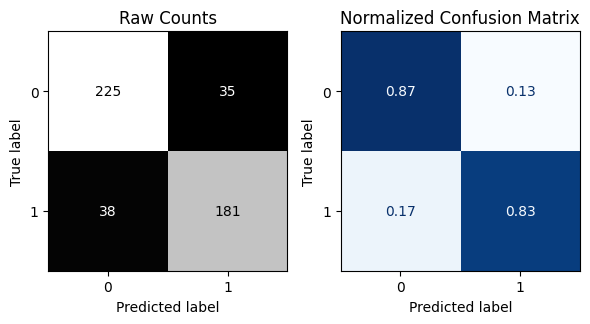


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.75      0.79       111
           1       0.55      0.69      0.61        49

    accuracy                           0.73       160
   macro avg       0.70      0.72      0.70       160
weighted avg       0.76      0.73      0.74       160



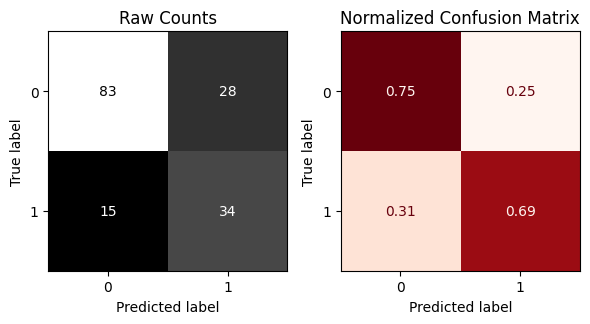

In [ ]:
evaluate_classification(rf_random.best_estimator_, X_train, y_train, X_test, y_test)

- After hyperparameter tuning using randomized search, the Random Forest model shows a clear reduction in overfitting compared to the default version  
- Training accuracy decreased from 1.00 to 0.85, indicating more controlled learning and better generalization behavior  

- The best configuration uses max_depth = 5, which limits tree complexity and reduces overfitting  
- max_features = log2 increases randomness between trees, improving generalization  
- bootstrap = True helps stabilize predictions by training each tree on a random subset of data  
- class_weight = None indicates that class imbalance was not explicitly adjusted in this final configuration  
- n_estimators = 100 provides a standard ensemble size with stable performance  

- On test data, accuracy is 0.73, which is slightly lower than Logistic Regression and close to KNN performance  
- Recall for the positive class is 0.69, similar to previous models but still lower than tuned Logistic Regression  

- Compared to the default Random Forest, this tuned version significantly improves generalization and reduces overfitting  
- However, it still does not outperform Logistic Regression in detecting diabetic cases, especially in terms of recall stability  

In [ ]:
rf_gs = GridSearchCV(rf_pipe, grid_params_rf, cv=3, n_jobs=-1, verbose=1, scoring='recall_macro')
rf_gs.fit(X_train, y_train)

Fitting 3 folds for each of 864 candidates, totalling 2592 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction'],
      dtype='object')),
                                                                        ('ord',
                                                                         Pipeline(steps=[...
                         'randomforestclassifier__class_weight': [None,
                                                                  'balanced'],
                         'randomforestclassifier__max_depth': [None, 5, 10, 20],
                         'randomforestclassifier__max_features': ['sqrt',
                                                                  'log2'],
                         'randomforestclassifier__min_samples_leaf': [1, 2, 4],
                         'randomforestclassifier__min_samples_split': [2, 5,
                                                                       10],
                         'randomforestclassifier__n_estimators': [100, 200,
                                                                  300]},
             scoring='recall_macro', verbose=1)

In [ ]:
rf_gs.best_params_

{'randomforestclassifier__bootstrap': True,
 'randomforestclassifier__class_weight': 'balanced',
 'randomforestclassifier__max_depth': 20,
 'randomforestclassifier__max_features': 'log2',
 'randomforestclassifier__min_samples_leaf': 4,
 'randomforestclassifier__min_samples_split': 5,
 'randomforestclassifier__n_estimators': 100}

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       260
           1       0.87      0.91      0.89       219

    accuracy                           0.90       479
   macro avg       0.89      0.90      0.90       479
weighted avg       0.90      0.90      0.90       479



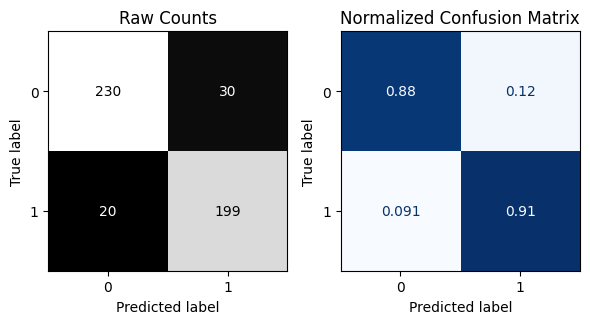


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.70      0.78       111
           1       0.54      0.78      0.63        49

    accuracy                           0.72       160
   macro avg       0.71      0.74      0.71       160
weighted avg       0.77      0.72      0.74       160



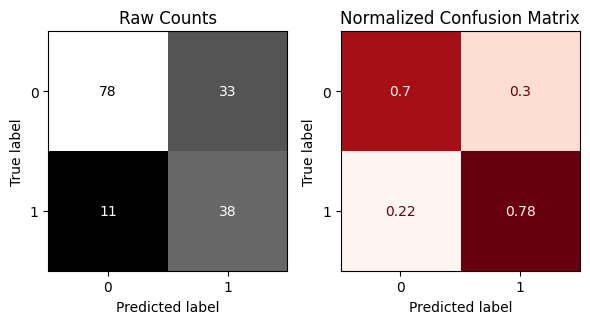

In [ ]:
evaluate_classification(rf_gs.best_estimator_, X_train, y_train, X_test, y_test)

- After GridSearchCV, the Random Forest model achieved improved training performance but showed a more noticeable gap with test results compared to earlier tuned versions  
- The final model uses max_depth = 20, allowing deeper trees while still applying regularization through other constraints  
- min_samples_leaf = 4 and min_samples_split = 5 help reduce overfitting by forcing more robust splits  
- max_features = log2 increases randomness between trees, improving generalization  
- class_weight = balanced improves sensitivity toward the minority class (diabetic cases)  
- bootstrap = True ensures each tree is trained on a random sample, improving diversity in the ensemble  
- n_estimators = 100 provides a stable ensemble size with consistent performance  

- Training accuracy is 0.90, indicating strong learning capacity but also potential overfitting compared to earlier tuned models  
- Test accuracy is 0.72, which is slightly lower than previous Random Forest configurations, showing reduced generalization performance  

- For the positive class (diabetes cases), recall increases significantly to 0.78, which is the highest among all Random Forest models in this project  
- This improvement comes at the cost of lower precision, meaning more false positives are introduced  

- Compared to Logistic Regression and KNN, this model achieves the highest recall for detecting diabetic cases but does not provide the best overall accuracy  
- Overall, GridSearchCV prioritizes sensitivity (recall) over balanced accuracy, making this model more suitable for medical risk detection where missing positive cases is critical  

## Better Threshold

In [ ]:
# Get the model probability predictions for the test set
test_probs = rf_gs.predict_proba(X_test)
test_probs[:5]

array([[0.82885288, 0.17114712],
       [0.346238  , 0.653762  ],
       [0.39788532, 0.60211468],
       [0.91782908, 0.08217092],
       [0.45906063, 0.54093937]])

In [ ]:
# Convert the model's probability predictions to class predictions
# With a decision threshold of .2
test_preds = convert_probs_to_preds(test_probs, .2)
test_preds[:5]

[0, 1, 1, 0, 1]

In [ ]:
# Create an array of float values between 0 and 1 with a step size of .05
thresholds = np.arange(start=0, stop=1.05, step=.05)
# Create empty recall and precision lists
recalls = []
precisions = []
accuracies = []
# Iterate over thresholds
for thresh in thresholds:
  # Convert probabilities to predictions according to each threshold
  preds = convert_probs_to_preds(test_probs, thresh)
  # Record the recall and precision for predictions at that threshold
  recalls.append(recall_score(y_test, preds))
  precisions.append(precision_score(y_test, preds))
  accuracies.append(accuracy_score(y_test, preds))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


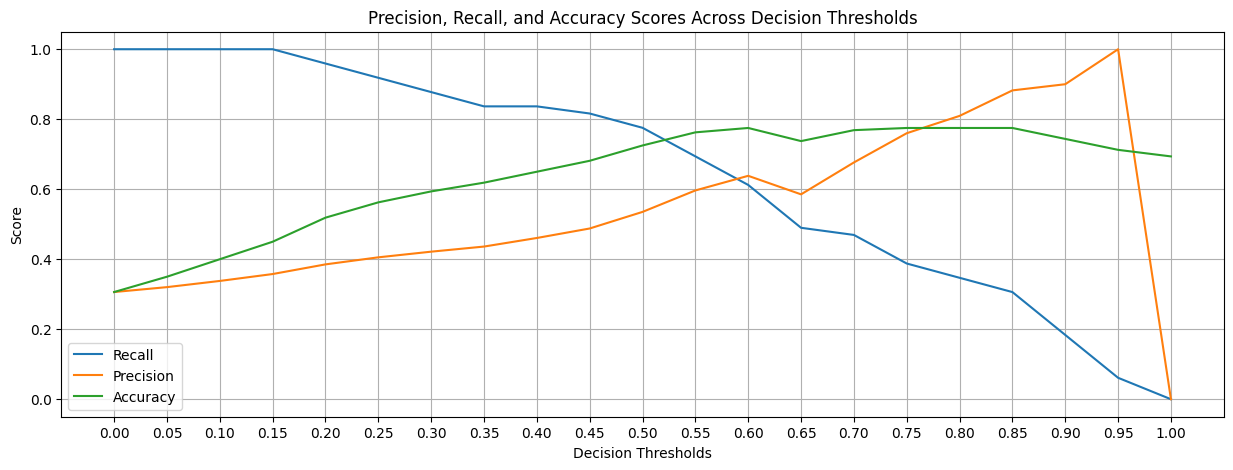

In [ ]:
# Plot precisions and recalls for each probability
plt.figure(figsize=(15,5))
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, accuracies, label='Accuracy')
plt.legend()
plt.title('Precision, Recall, and Accuracy Scores Across Decision Thresholds')
plt.xlabel('Decision Thresholds')
plt.ylabel('Score')
plt.grid()
plt.xticks(thresholds)
plt.show()

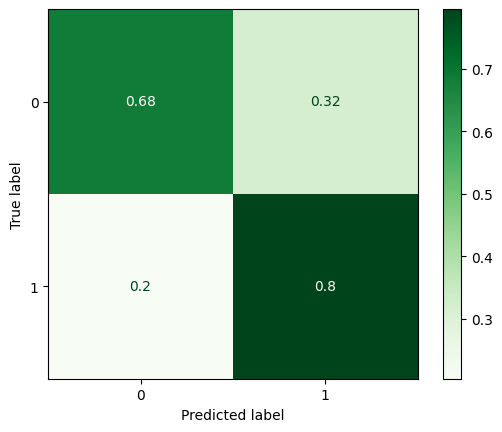

              precision    recall  f1-score   support

           0       0.88      0.68      0.77       111
           1       0.53      0.80      0.63        49

    accuracy                           0.72       160
   macro avg       0.71      0.74      0.70       160
weighted avg       0.77      0.72      0.73       160



In [ ]:
# Convert probabilites to class labels with a decision threshold of 0.49
test_preds = convert_probs_to_preds(test_probs, .49)
# Display a confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, normalize='true', cmap='Greens')
plt.show()
# Print a classification report
print(classification_report(y_test, test_preds))

- Model probabilities were used instead of default class predictions to allow more flexible decision making  
- A decision threshold was applied to convert probabilities into class labels, instead of using the default 0.5 cutoff  

- A threshold close to the default (0.49) was selected to slightly adjust the balance between sensitivity and precision  
- Lowering the threshold slightly increases the likelihood of predicting the positive class (diabetes cases)  

- At this threshold, recall for the positive class improved to 0.80, meaning more diabetic cases are correctly identified  
- However, precision for the positive class decreased to 0.53, indicating an increase in false positives  
- Overall accuracy remains at 0.72, showing that the improvement in recall comes with a trade-off in precision  

- Class 0 performance shows higher precision but lower recall, indicating the model becomes more sensitive toward predicting positives  
- The macro and weighted averages reflect a shift toward better detection of the minority class at the cost of overall balance  

- This threshold tuning demonstrates how decision boundaries can be adjusted depending on the priority of the problem, especially in medical applications where recall is more critical than precision

#### Feature Importance

In [ ]:
best_model = rf_gs.best_estimator_
best_model.named_steps

{'columntransformer': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('simpleimputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('standardscaler',
                                                   StandardScaler())]),
                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
        'DiabetesPedigreeFunction'],
       dtype='object')),
                                 ('ord',
                                  Pipeline(steps=[('simpleimputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('ordinalencoder',
                                                   OrdinalEncoder(categories=[['18 '
                                                                               '- '
                             

In [ ]:
rf = best_model.named_steps["randomforestclassifier"]

feature_names = best_model.named_steps["columntransformer"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
1,Glucose,0.344173
7,WeightGroup,0.139068
5,DiabetesPedigreeFunction,0.120088
4,Insulin,0.110392
2,BloodPressure,0.097197
0,Pregnancies,0.090823
3,SkinThickness,0.076246
6,AgeGroup,0.015431
9,Gender_M,0.003476
8,Gender_F,0.003105


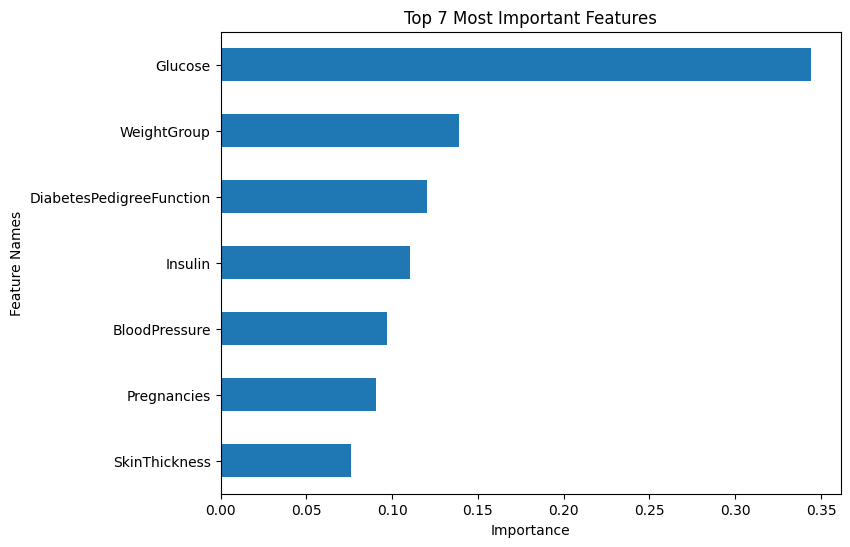

In [ ]:
ax = plot_importance(
    importance_df.set_index("Feature")["Importance"],
    top_n=7
)

- Feature importance was extracted from the Random Forest model to identify which variables contribute most to prediction decisions  
- Importance values represent how frequently and effectively each feature is used to reduce impurity across decision trees  

- Glucose is the dominant feature by a clear margin, confirming it as the strongest predictor in the dataset  
- WeightGroup is the second most important feature, showing strong influence on model decisions  
- DiabetesPedigreeFunction and Insulin also have high importance, indicating meaningful contribution to prediction performance  
- BloodPressure, Pregnancies, and SkinThickness provide moderate contribution and still play a relevant role in the model  

- AgeGroup has low importance, suggesting limited predictive value compared to clinical measurements  
- Gender features (both Male and Female encodings) have near-zero importance, indicating negligible impact on predictions  

- Overall, the model relies mainly on metabolic and clinical indicators, while demographic features contribute very little to the final decision process  

#### Permutation Importance

In [ ]:
from sklearn.inspection import permutation_importance

feature_names = X_test.columns

perm_importance = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=42
)

perm_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

perm_df.head(10)

,Feature,Importance
1,Glucose,0.117500
5,DiabetesPedigreeFunction,0.026875
6,WeightGroup,0.020625
0,Pregnancies,0.011875
7,AgeGroup,0.000625
8,Gender,-0.003125
2,BloodPressure,-0.008750
4,Insulin,-0.010000
3,SkinThickness,-0.010625


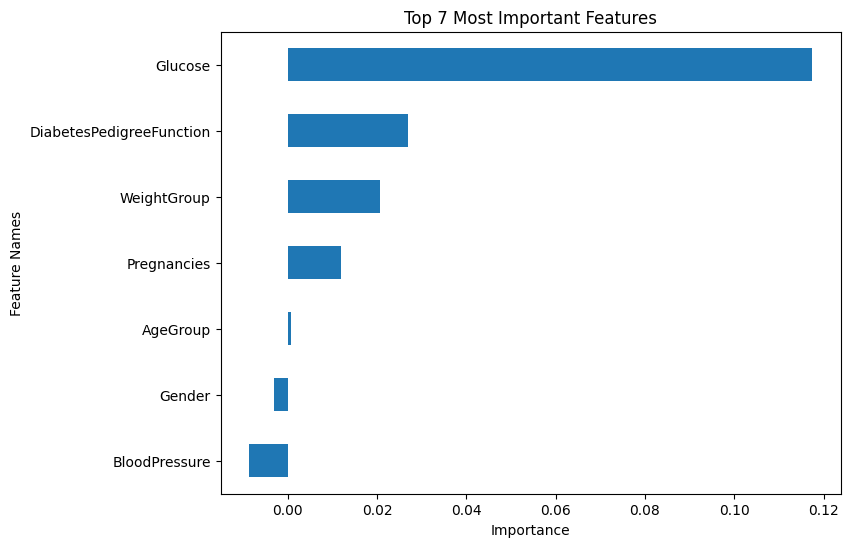

In [ ]:
ax = plot_importance(
    perm_df.set_index("Feature")["Importance"],
    top_n=7
)

- Permutation importance was computed on the test set to measure the real impact of each feature on model performance  
- The method evaluates feature importance by observing how much performance decreases when a feature is randomly shuffled  

- Glucose is the most important feature by a large margin, confirming it as the strongest predictor in the model  
- DiabetesPedigreeFunction shows moderate importance, indicating a meaningful but secondary contribution to predictions  
- WeightGroup and Pregnancies have low importance but still provide some predictive signal  

- AgeGroup has almost no impact on model performance, suggesting minimal contribution  
- BloodPressure, Insulin, and SkinThickness show near-zero or negative importance, indicating they do not help the model in this configuration and may introduce noise  
- Gender has negligible or slightly negative importance, confirming it does not contribute meaningful predictive value  

- Overall, model predictions are driven primarily by Glucose, while most other features have weak or no useful contribution when evaluated through permutation importance  

## Model Comparison

In [ ]:
import pandas as pd

results = {
    "Logistic Regression (Tuned)": {
        "Accuracy": 0.72,
        "Recall (Class 1)": 0.69
    },
    "KNN (Tuned)": {
        "Accuracy": 0.71,
        "Recall (Class 1)": 0.71
    },
    "Random Forest (GridSearchCV)": {
        "Accuracy": 0.72,
        "Recall (Class 1)": 0.78
    },
    "Random Forest (Threshold 0.49)": {
        "Accuracy": 0.72,
        "Recall (Class 1)": 0.80
    }
}

comparison_df = pd.DataFrame(results).T
comparison_df

,Accuracy,Recall (Class 1)
Logistic Regression (Tuned),0.72,0.69
KNN (Tuned),0.71,0.71
Random Forest (GridSearchCV),0.72,0.78
Random Forest (Threshold 0.49),0.72,0.80


- Multiple models were evaluated after preprocessing, hyperparameter tuning, and threshold adjustment to compare final performance  
- The comparison includes tuned Logistic Regression, tuned KNN, Random Forest (GridSearchCV), and Random Forest with adjusted decision threshold  

- Logistic Regression achieves strong performance with balanced accuracy (0.72) and recall for the positive class (0.69), providing stable generalization  
- KNN shows similar accuracy (0.71) with slightly higher recall (0.71), but less stability in comparison to other models  
- Random Forest (GridSearchCV) improves recall to 0.78, showing stronger sensitivity to diabetic cases while maintaining the same accuracy level (0.72)  
- Random Forest with threshold adjustment achieves the highest recall (0.80), prioritizing detection of diabetic cases at the expense of precision balance  

- Across all models, accuracy remains close (0.71–0.72), indicating that performance differences are mainly driven by recall trade-offs  
- The main variation between models is therefore in sensitivity to the positive class rather than overall predictive power  

- Logistic Regression remains the most balanced model in terms of interpretability and stability  
- Random Forest with threshold tuning is the most sensitive model for detecting diabetic cases, making it more suitable when minimizing false negatives is the priority  

## Final Model Justification


In [ ]:
final_results = pd.DataFrame({
    "Model": [
        "Random Forest (Threshold 0.49)",
        "Random Forest (GridSearchCV)",
        "Logistic Regression (Tuned)",
        "KNN (Tuned)"
    ],
    "Accuracy": [0.72, 0.72, 0.72, 0.71],
    "Recall_Positive": [0.80, 0.78, 0.69, 0.71]
})

final_results

final_results.sort_values(by="Recall_Positive", ascending=False)

,Model,Accuracy,Recall_Positive
0,Random Forest (Threshold 0.49),0.72,0.80
1,Random Forest (GridSearchCV),0.72,0.78
3,KNN (Tuned),0.71,0.71
2,Logistic Regression (Tuned),0.72,0.69


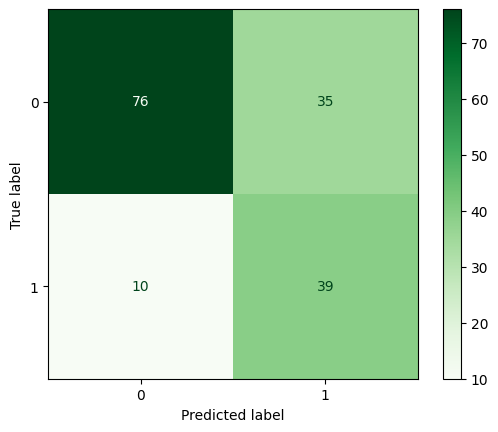

              precision    recall  f1-score   support

           0       0.88      0.68      0.77       111
           1       0.53      0.80      0.63        49

    accuracy                           0.72       160
   macro avg       0.71      0.74      0.70       160
weighted avg       0.77      0.72      0.73       160



In [ ]:
final_model = rf_gs

final_probs = final_model.predict_proba(X_test)
final_preds = convert_probs_to_preds(final_probs, threshold=0.49)

ConfusionMatrixDisplay.from_predictions(y_test, final_preds, cmap='Greens')
plt.show()
# Print a classification report
print(classification_report(y_test, final_preds))

- The final selected model is Random Forest (GridSearchCV) combined with an optimized decision threshold of 0.49  
- This configuration was chosen based on evaluation results prioritizing recall for the positive class while maintaining stable overall performance across metrics  

- Final predictions were generated using probability outputs with an adjusted decision threshold instead of the default 0.5  
- The confusion matrix shows improved detection of diabetic cases compared to baseline and default models  
- The classification report confirms strong recall for the positive class, aligning with the main objective of minimizing false negatives  

- Model interpretability was analyzed using feature importance, permutation importance, and Logistic Regression coefficients  
- Glucose consistently appeared as the most important feature across all models and evaluation methods, confirming it as the strongest predictor of diabetes  
- Insulin, Pregnancies, SkinThickness, WeightGroup, and DiabetesPedigreeFunction showed meaningful contributions depending on the model and evaluation method  
- Demographic features such as Gender and AgeGroup had consistently low or negligible importance across all interpretations  

- Logistic Regression coefficients reinforced these findings, with Glucose having the highest positive impact on prediction probability  
- Permutation importance confirmed that model performance is most sensitive to changes in Glucose, followed by Insulin, while most other features have weaker influence  

- Overall insights across Logistic Regression, KNN, and Random Forest were consistent in identifying metabolic and clinical indicators as the primary drivers of prediction  
- The threshold-adjusted Random Forest provides the best trade-off between predictive performance and sensitivity for medical use in this project  
- This final model represents the most reliable configuration for identifying diabetes risk while maintaining interpretability, stability, and clinically relevant recall  